<a href="https://colab.research.google.com/github/cintiapinho/Aulas_FATEC_PLN/blob/main/Materiais/Aula_5_6_ExtracaoCaracteristicas_ML_em_PLN/Extracao_carac_ML_notebook_pratica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sessões 05 e 06 — Extração de Características e Análise de Sentimentos I

**Processamento de Linguagem Natural**

Notebook de prática guiada — com as mesmas definições e explicações do PPTX. Se você prefere estudar direto por aqui, sem abrir o slide, este notebook é auto-suficiente.

Hoje é uma aula com dobro de conteúdo por conta das reposições de aula — duas sessões no mesmo dia. Primeiro **Extração de características**: transformar texto em número, pra qualquer modelo de Machine Learning conseguir usar. Depois **Análise de Sentimentos I**: a primeira aplicação prática dessa ideia — descobrir se um texto é positivo ou negativo, começando pela abordagem mais simples que existe, o léxico de palavras.

Vampos usar o dataset **HateBR** (7.000 comentários do Instagram, anotados como ofensivos ou não — VARGAS et al., 2022), que já apareceu nas Sessões 03-04. Vamos usá-lo de novo nas duas partes de hoje, comparando abordagens diferentes pro mesmo problema.

In [ ]:
teste = 'cintia'

In [ ]:
# ===== Setup =====
import re
import math
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from nltk import ngrams
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# detector ingênuo das Sessões 03-04
lista_proibida = {"idiota", "burro", "imbecil"}
def contem_linguagem_inadequada(frase, lista_proibida):
    tokens = frase.lower().split()
    return any(t.strip('.,!?') in lista_proibida for t in tokens)

# corpus de reviews usado na Parte 1
reviews = [
    "produto excelente, chegou rapido, adorei",
    "produto horrivel, chegou quebrado, nao funciona",
    "nao gostei, atendimento pessimo",
    "amei o produto, super recomendo",
]



## Parte 1 — Extração de características

### 1.1 Do texto ao número

Algoritmos de Machine Learning não leem texto — trabalham só com números. Pra usar qualquer modelo de classificação, regressão ou agrupamento sobre texto, é preciso primeiro transformar cada documento numa lista de números: um **vetor**. Esse processo se chama **vetorização** (GÉRON, 2019).

O problema que qualquer vetorização precisa resolver:

```
Review A: "produto excelente, chegou rápido, adorei"
Review B: "produto horrível, chegou quebrado, odiei"
```

As duas contêm "produto" e "chegou" — mas têm sentimentos opostos. Uma boa representação numérica precisa dar peso às palavras que **diferenciam** os dois textos, não só contar palavras em comum.

### 1.2 Bag of Words

**Bag of Words** (BoW, "saco de palavras") representa um texto pela contagem de cada palavra do vocabulário, jogando fora completamente a ordem em que elas aparecem — como se você despejasse todas as palavras do documento dentro de um saco: o que sobra é só "quais palavras tem, e quantas de cada", não mais "em que ordem estavam" (GÉRON, 2019). Formalmente, cada documento vira um vetor de contagens sobre o vocabulário do corpus inteiro.

`CountVectorizer`, do scikit-learn, calcula isso automaticamente — sem precisar do `FreqDist` manual que usamos nas Sessões 03-04.

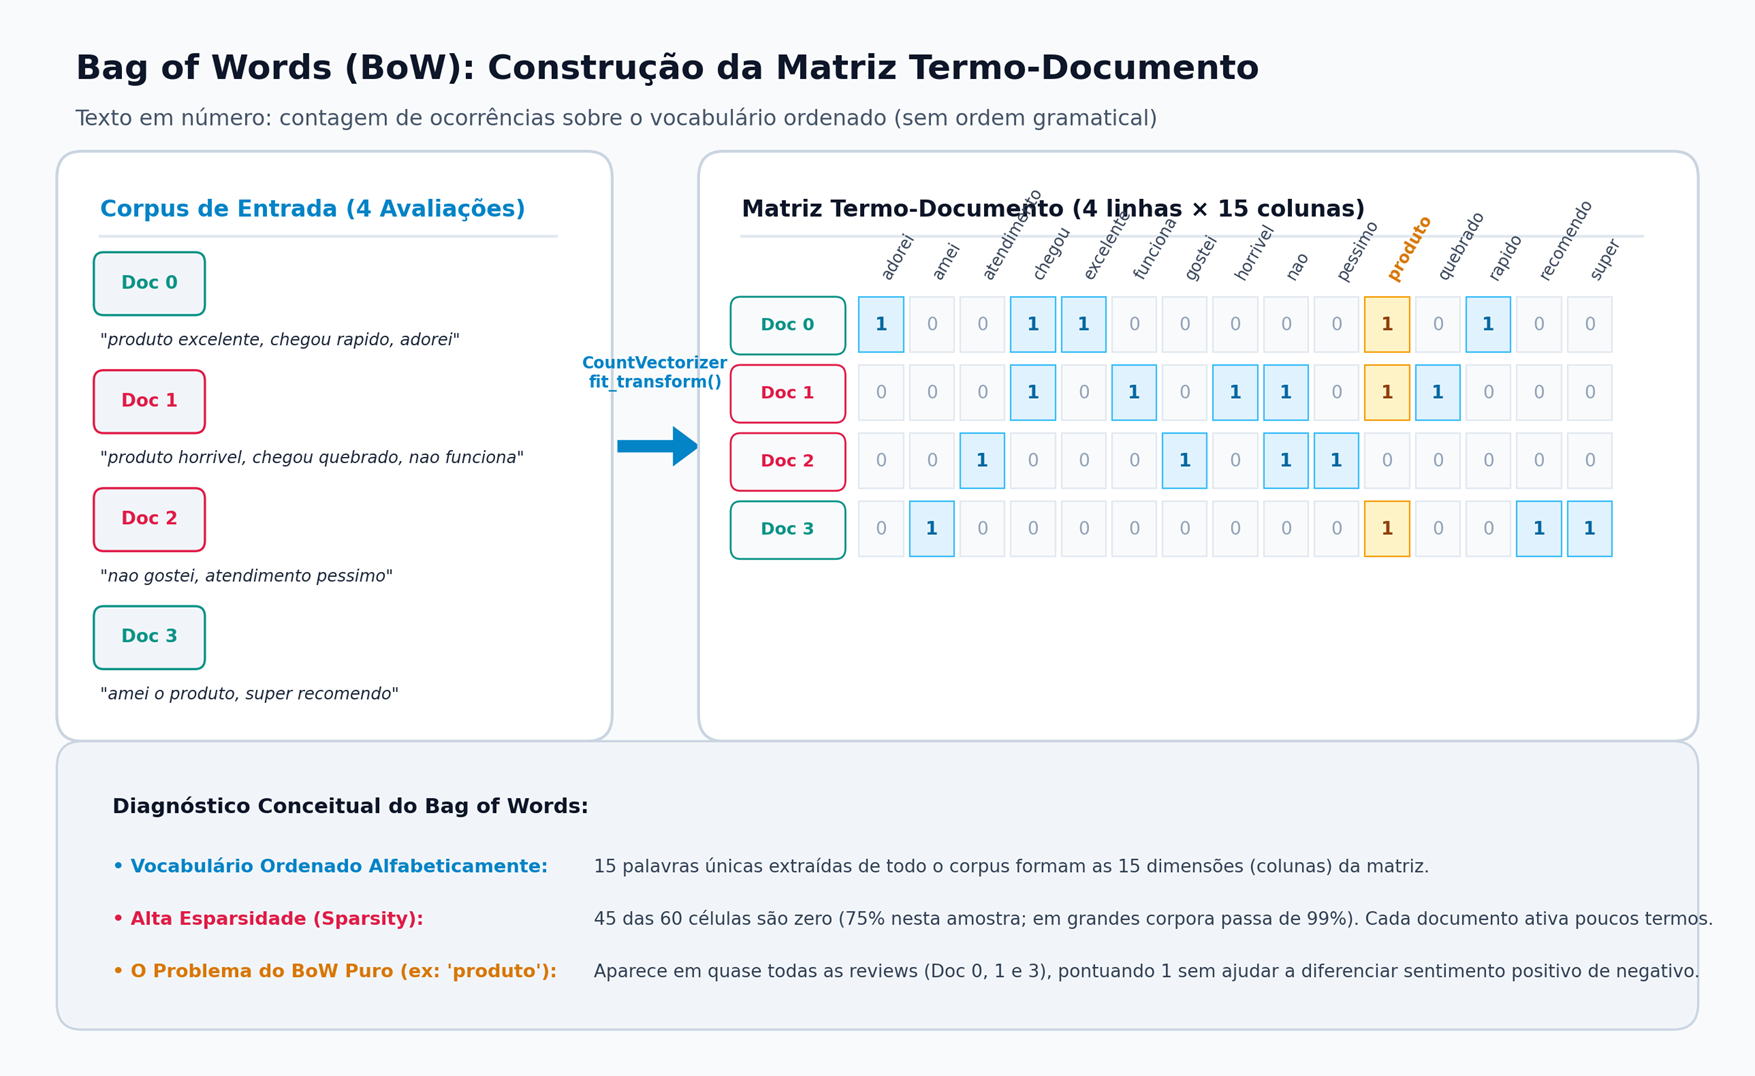

In [ ]:
cv = CountVectorizer()
matriz_bow = cv.fit_transform(reviews)

print("Vocabulário:", sorted(cv.vocabulary_.keys()))
print(matriz_bow.toarray())
print(matriz_bow)

Cada linha é um documento, cada coluna uma palavra do vocabulário — o valor é quantas vezes ela aparece. Repare que a maior parte da matriz é zero: essa é a **esparsidade**, característica normal do BoW. Em corpora com dezenas de milhares de documentos, a esparsidade costuma passar de 99% (GÉRON, 2019).

O problema do Bag of Words puro: "produto" aparece em quase toda review, positiva ou negativa — ele não ajuda a diferenciar nada, mas conta tanto quanto qualquer outra palavra.

#### Onde o Bag of Words é usado de verdade

Apesar de simples, BoW ainda aparece em produção — mas ainda veremos o TF-IDF que trata algumas limitações:

| Uso | Como o BoW ajuda |
|---|---|
| **Filtro de spam** | E-mails de spam repetem certas palavras ("grátis", "clique aqui") — contar já é sinal forte. |
| **Classificação de tópico** | Cada categoria (esporte, política, tecnologia) tem vocabulário característico. |
| **Busca e recuperação** | Comparar vetor da consulta com o de cada documento — a mesma ideia do RAG (Sessões 09-10). |
| **Similaridade entre documentos** | Agrupar textos parecidos (ex.: posts duplicados) comparando vetores de contagem. |

Um exemplo prático de busca: dado um pequeno conjunto de documentos e uma consulta, o BoW consegue apontar qual documento é mais parecido com a consulta, usando a mesma similaridade de cosseno que vimos com embeddings (Seção 1.5):

In [ ]:
documentos = [
    "o gato dorme no sofa da sala",
    "o cachorro corre atras da bola no parque",
    "o computador processa dados rapidamente",
    "a inteligencia artificial aprende com dados",
]
consulta = ["o cachorro brinca com a bola"]

cv_busca = CountVectorizer()
cv_busca.fit(documentos + consulta)
matriz_docs = cv_busca.transform(documentos)
vetor_consulta = cv_busca.transform(consulta)

similaridades = cosine_similarity(vetor_consulta, matriz_docs)[0]
for doc, sim in sorted(zip(documentos, similaridades), key=lambda x: -x[1]):
    print(f"{sim:.4f}  {doc}")

### Analisando os Resultados da Similaridade de Cosseno

Ao utilizar o `CountVectorizer` e a Similaridade de Cosseno, os resultados refletem puramente a contagem matemática das palavras, sem considerar o contexto ou a semântica.

**A nossa consulta foi:** `"o cachorro brinca com a bola"`

Por padrão, o scikit-learn descarta palavras com apenas um caractere (como "o" e "a"). Portanto, os tokens reais processados para a consulta são: `["cachorro", "brinca", "com", "bola"]`.

---

#### 1. Por que as duas últimas frases zeraram (0.0000)?
A métrica de *cosine similarity* compara os vetores gerados a partir da contagem dessas palavras. Se não houver nenhuma palavra em comum entre o documento e a consulta, o produto escalar é zero.

*   **Doc 3:** `"o gato dorme no sofa da sala"`
    *   Tokens: `["gato", "dorme", "no", "sofa", "da", "sala"]`
    *   **Intersecção:** Nenhuma palavra em comum com a consulta.
*   **Doc 4:** `"o computador processa dados rapidamente"`
    *   Tokens: `["computador", "processa", "dados", "rapidamente"]`
    *   **Intersecção:** Nenhuma palavra em comum com a consulta.

Sem "bag of words" compartilhadas, a distância vetorial aponta similaridade nula.

---

#### 2. Por que a frase sobre Inteligência Artificial pontuou (0.2236)?
Mesmo falando de um assunto completamente diferente da nossa consulta, a frase obteve uma similaridade maior que zero porque compartilha exatamente **uma palavra** (uma *stopword* não filtrada):

*   **Consulta:** "o cachorro brinca **com** a bola"
*   **Doc 4:** "a inteligencia artificial aprende **com** dados"

Como o *Bag of Words* enxerga apenas a presença e a frequência dos tokens, o simples fato da palavra **"com"** aparecer em ambos os textos faz com que os vetores se cruzem, gerando a pontuação.

> **💡 Dica Prática:**
> Esse comportamento demonstra por que, no desenvolvimento de projetos reais de NLP, geralmente aplicamos técnicas de remoção de **stopwords** (palavras vazias de significado, como "com", "de", "para") antes de vetorizar o texto. Se a palavra "com" fosse removida no pré-processamento, essa frase também teria similaridade `0.0000`.

O documento sobre o cachorro e a bola sai em primeiro, mesmo sem nenhuma palavra idêntica à consulta em posição igual — o BoW já captura a sobreposição de vocabulário. É uma versão simples exatamente do que um sistema de busca (ou um RAG) faz: vetorizar tudo e rankear por proximidade.

### 1.3 TF-IDF

O **TF-IDF** (*Term Frequency – Inverse Document Frequency*) resolve exatamente esse problema, dando peso menor a palavras que aparecem em muitos documentos e peso maior às que são raras — logo, mais específicas de um documento.

```
TF(t, d)    = contagem(t, d) / total de tokens em d
IDF(t, D)   = log( N / (df(t) + 1) )
TF-IDF(t,d) = TF(t, d) × IDF(t, D)

N     = número total de documentos
df(t) = número de documentos que contêm o termo t
```

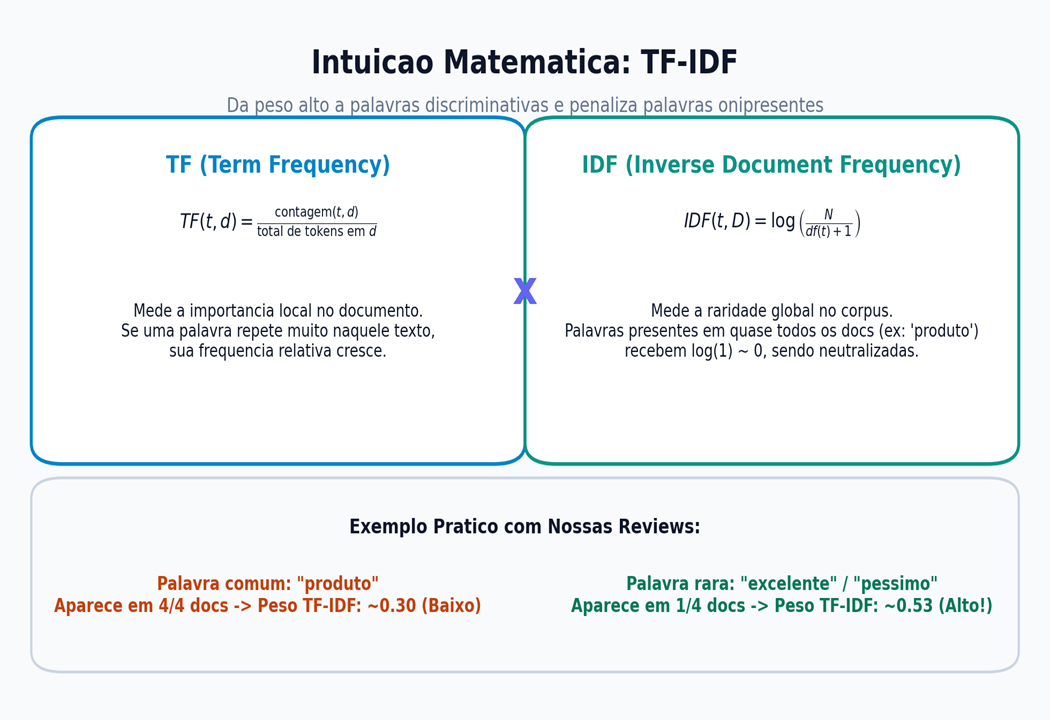

In [ ]:
reviews = [
    "produto excelente, chegou rapido, adorei",
    "produto horrivel, chegou quebrado, nao funciona",
    "nao gostei, atendimento pessimo",
    "amei o produto, super recomendo",
]

In [ ]:
# 1. Instancia o vetorizador TF-IDF.
tv = TfidfVectorizer()

# 2. Aprende o vocabulário da lista de textos 'reviews' (fit)
# e já transforma os textos na matriz numérica de pesos (transform).
# O resultado é uma matriz esparsa (otimizada para gastar menos memória, guardando apenas valores > 0).
matriz_tfidf = tv.fit_transform(reviews)

# 3. Configura a forma como o NumPy vai imprimir os arrays na tela.
# precision=2: Limita a exibição a apenas 2 casas decimais.
# suppress=True: Impede que o NumPy use notação científica (ex: 1.2e-04),
# forçando a exibição de números decimais normais (ex: 0.00), o que facilita muito a leitura.
np.set_printoptions(precision=2, suppress=True)

# 4. Imprime a matriz resultante.
print(matriz_tfidf.toarray())

### Entendendo a Matriz TF-IDF na Prática

Quando olhamos para a matriz gerada, estamos vendo a transformação dos nossos textos em vetores matemáticos.
*   **Linhas:** Representam cada um dos nossos documentos (as *reviews*).
*   **Colunas:** Representam cada palavra única do nosso vocabulário.

---

#### 1. O Vocabulário (As Colunas)
O modelo extrai todas as palavras únicas dos textos, ignora palavras de uma letra e as organiza em ordem alfabética. Nosso vocabulário gerou exatamente **15 palavras** (resultando em 15 colunas).

| Índice | Palavra | Índice | Palavra | Índice | Palavra |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **0** | adorei | **5** | funciona | **10** | produto |
| **1** | amei | **6** | gostei | **11** | quebrado |
| **2** | atendimento| **7** | horrivel | **12** | rapido |
| **3** | chegou | **8** | nao | **13** | recomendo |
| **4** | excelente | **9** | pessimo | **14** | super |

---

#### 2. Analisando a Primeira Linha (Doc 1)
Vamos isolar a primeira frase: *"produto excelente, chegou rapido, adorei"* e observar a primeira linha da matriz:

`[0.50, 0., 0., 0.39, 0.50, 0., 0., 0., 0., 0., 0.32, 0., 0.50, 0., 0.]`

Os zeros indicam as palavras do vocabulário que **não** aparecem na frase. Onde há números maiores que zero, o TF-IDF revela sua principal vantagem em relação à simples contagem de palavras (*Bag of Words*):

*   **Peso Baixo (0.32) - "produto" (coluna 10):** É o menor peso da linha. Como a palavra "produto" aparece em quase todas as frases do *dataset*, o modelo entende que ela é comum e tem pouco poder de diferenciar um texto do outro. O TF-IDF "pune" palavras muito frequentes no *corpus*.
*   **Peso Intermediário (0.39) - "chegou" (coluna 3):** Não é tão comum quanto "produto", mas também não é exclusiva, pois aparece em mais de uma frase (Doc 1 e Doc 2).
*   **Peso Alto (0.50) - "adorei" (col. 0), "excelente" (col. 4) e "rapido" (col. 12):** São os maiores pesos. Como essas palavras aparecem **apenas** nesta frase, o algoritmo as considera "raras" no contexto geral e cruciais para identificar o sentido específico deste documento.

---

#### 3. Conclusão
O TF-IDF não está apenas contando palavras, ele cria uma **assinatura de relevância**.

> **💡 Nota:** Se fôssemos treinar um modelo para classificar essas *reviews* entre positivas ou negativas, o algoritmo já facilitou o trabalho: ele deu um peso muito maior para palavras que indicam sentimento (como "adorei" e "excelente") e reduziu matematicamente o impacto de palavras genéricas (como "produto").


Existe uma terceira opção, `HashingVectorizer`: em vez de guardar um dicionário palavra→coluna na memória, ele calcula a coluna de cada palavra por uma função de hash. Fica mais rápido e usa menos memória em corpus gigantes ou em streaming, mas colisões de hash podem juntar duas palavras diferentes na mesma coluna, e não dá pra recuperar o vocabulário original a partir da matriz. Fica registrado que existe — não vamos usá-lo hoje.

### 1.4 N-gramas

Tanto o BoW quanto o TF-IDF, do jeito que vimos até aqui, tratam cada palavra isolada — um **unigrama**. O problema: "não funciona" vira dois tokens separados, "não" e "funciona", perdendo a ligação entre os dois.

Um **n-grama** é uma sequência de *n* palavras consecutivas. Pra um texto com *T* tokens, o número de n-gramas possíveis é `T - n + 1`:

- **Unigrama** (n=1): cada palavra sozinha.
- **Bigrama** (n=2): pares consecutivos — "não funciona" vira um token só.
- **Trigrama** (n=3): trios consecutivos — "não gostei nada" vira um token só.

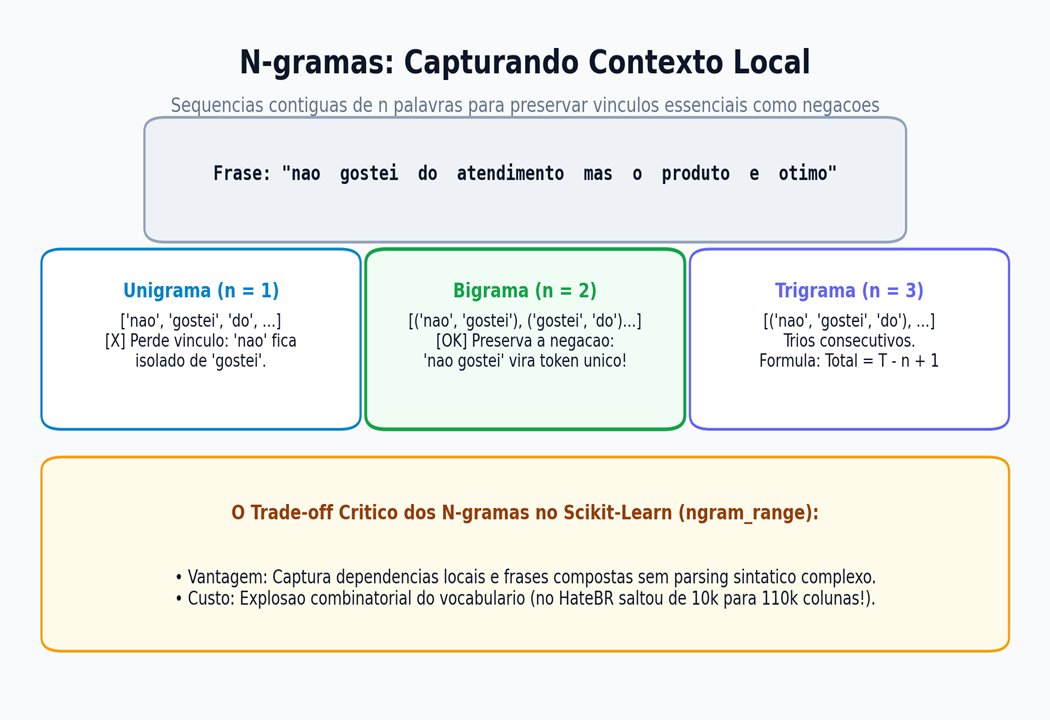

In [ ]:
frase = "nao gostei do atendimento mas o produto e otimo"
tokens = word_tokenize(frase, language="portuguese")

print("Bigramas:", list(ngrams(tokens, 2)))
print("Trigramas:", list(ngrams(tokens, 3)))

Na prática, não é preciso montar os n-gramas na mão: tanto `CountVectorizer` quanto `TfidfVectorizer` aceitam o parâmetro `ngram_range`:

In [ ]:
# O parâmetro ngram_range=(1, 2) ensina o modelo a olhar não apenas para palavras isoladas (unigramas = 1),
# mas TAMBÉM para pares de palavras consecutivas (bigramas = 2).
tv_bigrama = TfidfVectorizer(ngram_range=(1, 2))

# 2. O modelo lê a lista de textos ('reviews') e aprende o vocabulário,
# extraindo todas as palavras únicas e todos os pares de palavras.
tv_bigrama.fit(reviews)

# 3. Esta linha usa um recurso do Python (list comprehension) para filtrar o vocabulário gerado.
# get_feature_names_out() devolve tudo o que o modelo aprendeu.
# O 'if "nao" in f' faz com que o print exiba APENAS as features que contêm a palavra "nao".
print([f for f in tv_bigrama.get_feature_names_out() if "nao" in f])

### Por que não vimos as 4 frases na saída?

A resposta curta é: **o código não imprimiu as *reviews*, ele imprimiu um pedaço do vocabulário gerado.**

Vamos entender o passo a passo do que aconteceu:

#### 1. A criação do Vocabulário (`fit`)
Quando rodamos `tv_bigrama.fit(reviews)`, o modelo leu todas as 4 frases juntas e extraiu todas as palavras únicas (unigramas) e todos os pares (bigramas). Ele não olha mais para as frases como unidades separadas, mas sim como um grande "dicionário" global do nosso *dataset*.

#### 2. A extração das *Features*
O comando `tv_bigrama.get_feature_names_out()` devolve esse dicionário completo (todas as *features* que o modelo aprendeu).

#### 3. O Filtro em Ação (List Comprehension)
A mágica que reduziu a saída acontece no final da linha: `if "nao" in f`.
Isso diz ao Python: *"Varra esse dicionário gigantesco e imprima na tela **apenas** os termos que contêm a palavra 'nao'."*

#### 4. Analisando as Frases Originais
Se olharmos para as nossas 4 frases, fica claro de onde vieram os termos filtrados:

1. *"produto excelente, chegou rapido, adorei"* ➡️ (Ignorada pelo filtro, sem "nao")
2. *"produto horrivel, chegou quebrado, **nao** funciona"* ➡️ (Gerou: `'nao'`, `'quebrado nao'`, `'nao funciona'`)
3. *"**nao** gostei, atendimento pessimo"* ➡️ (Gerou: `'nao'`, `'nao gostei'`)
4. *"amei o produto, super recomendo"* ➡️ (Ignorada pelo filtro, sem "nao")

**Conclusão:** A saída `['nao', 'nao funciona', 'nao gostei', 'quebrado nao']` reflete puramente as características (*features*) matemáticas extraídas das frases 2 e 3, e não os documentos originais inteiros.

### Por que vieram Unigramas e Bigramas juntos?

Isso aconteceu por conta da configuração desta linha de código:

`ngram_range=(1, 2)`

O parâmetro `ngram_range` recebe uma tupla que define o tamanho **mínimo** e **máximo** dos n-gramas que o modelo deve extrair. Ele sempre gera todas as combinações que estão dentro desse intervalo:

*   O **1** inicial diz ao modelo: *"Extraia todas as palavras isoladas (unigramas)"*.
*   O **2** final diz ao modelo: *"Vá até o tamanho de 2 palavras, extraindo também os pares (bigramas)"*.

Como o intervalo vai de 1 até 2, ele mistura os dois tipos no vocabulário final. Isso é muito útil na prática porque você ganha o contexto do bigrama (ex: "nao gostei") sem perder a informação matemática de quantas vezes a palavra solta (ex: "gostei") apareceu sozinha no resto do texto.

---

#### 💡 Como trazer SOMENTE bigramas?
Se você quisesse que o modelo ignorasse as palavras soltas e gerasse estritamente os pares de palavras, bastaria alterar o intervalo para começar e terminar no número 2:

```python
# O intervalo (2, 2) força o modelo a extrair APENAS bigramas
tv_so_bigrama = TfidfVectorizer(ngram_range=(2, 2))

### 1.5 Word Embeddings (visão geral)

BoW, TF-IDF e n-gramas têm uma limitação em comum: nenhum entende significado. Pra essas técnicas, "bom" e "excelente" são duas colunas completamente independentes — não têm nada em comum, mesmo sendo praticamente sinônimos.

**Word embeddings** resolvem isso representando cada palavra como um vetor **denso** (poucos números, todos preenchidos, sem os zeros do BoW) num espaço onde palavras de significado parecido ficam **próximas**.

Os números abaixo são **ilustrativos** — não vêm de nenhum modelo treinado agora, só servem pra mostrar a ideia. O treino de verdade (Word2Vec, com `gensim`) fica pra Sessão 08, junto com redes neurais e Transformers.

Na prática da área de IA e NLP no Brasil, o termo Word Embeddings raramente é traduzido; a comunidade adota o nome original em inglês mesmo.

No entanto, quando precisamos traduzir em livros ou materiais acadêmicos, os termos mais utilizados são:

Representação vetorial de palavras (a mais descritiva e ideal para explicar o conceito).

Incorporação de palavras (a tradução mais literal).

Por que "incorporação"?
O termo vem da ideia de que estamos pegando um conceito solto (uma palavra) e "incorporando" (ou seja, mapeando/inserindo) ele dentro de um espaço matemático tridimensional, na forma de um vetor (aquela lista de números).

In [ ]:
def similaridade_cosseno(v1, v2):
    # Calcula o produto escalar (multiplica posições iguais e soma)
    produto = sum(a * b for a, b in zip(v1, v2))
    # Calcula o comprimento (norma euclidiana) do vetor 1
    norma1 = math.sqrt(sum(a * a for a in v1))
    # Calcula o comprimento (norma euclidiana) do vetor 2
    norma2 = math.sqrt(sum(a * a for a in v2))
    # Retorna a similaridade (próximo de 1 = muito similar, 0 = diferente)
    return produto / (norma1 * norma2)

# Vetor (embedding) simulado para a palavra "bom"
bom = [0.80, 0.30, 0.50]
# Vetor para "excelente", com valores matemáticos propositalmente próximos
excelente = [0.78, 0.32, 0.48]
# Vetor para "carro", com valores matemáticos bem distantes dos anteriores
carro = [0.10, -0.60, 0.20]

# O resultado será próximo de 1, confirmando a semelhança semântica
print("cos(bom, excelente) =", round(similaridade_cosseno(bom, excelente), 4))
# O resultado será 0, confirmando que as palavras não têm relação
print("cos(bom, carro)     =", round(similaridade_cosseno(bom, carro), 4))

### Como se chega nesses valores na vida real?

Esses vaores servem apenas para provar matematicamente que vetores com números parecidos geram um cosseno próximo a 1.

# Vetor (embedding) simulado para a palavra "bom"
bom = [0.80, 0.30, 0.50]
# Vetor para "excelente", com valores matemáticos propositalmente próximos
excelente = [0.78, 0.32, 0.48]
# Vetor para "carro", com valores matemáticos bem distantes dos anteriores
carro = [0.10, -0.60, 0.20]

Esses vetores densos (curtos e cheios de números, sem os zeros de uma matriz esparsa) são chamados de **Word Embeddings**. Diferente de técnicas como Bag of Words e TF-IDF, eles não são criados por simples contagem, mas sim *aprendidos* por **Redes Neurais** (em modelos famosos como Word2Vec, GloVe ou Transformers).

O processo de treinamento funciona, de forma resumida, nas seguintes etapas:

*   **1. Leitura em Massa:** A rede neural é alimentada com gigabytes (ou terabytes) de textos reais, como a Wikipedia inteira, livros e artigos de internet.
*   **2. Análise de Contexto:** O modelo brinca de "adivinhar as lacunas". Ele tenta prever palavras ocultas em uma frase baseando-se nas palavras vizinhas. Durante esse processo, ele percebe que palavras como *"bom"* e *"excelente"* costumam estar rodeadas pelas exatas mesmas estruturas textuais (ex: *"ele fez um ___ trabalho"*, *"foi um ___ filme"*).
*   **3. Ajuste de Pesos:** Por aparecerem nos mesmos contextos de forma repetida, a matemática da rede neural vai ajustando gradativamente os vetores dessas duas palavras. O resultado final é que seus números ficam quase idênticos, refletindo a semelhança de significado.

> **💡 O Grande Diferencial:** Enquanto o TF-IDF mapeia apenas a **frequência** das palavras no seu documento, os Embeddings mapeiam o **significado** delas com base na forma como são realmente usadas na linguagem humana.

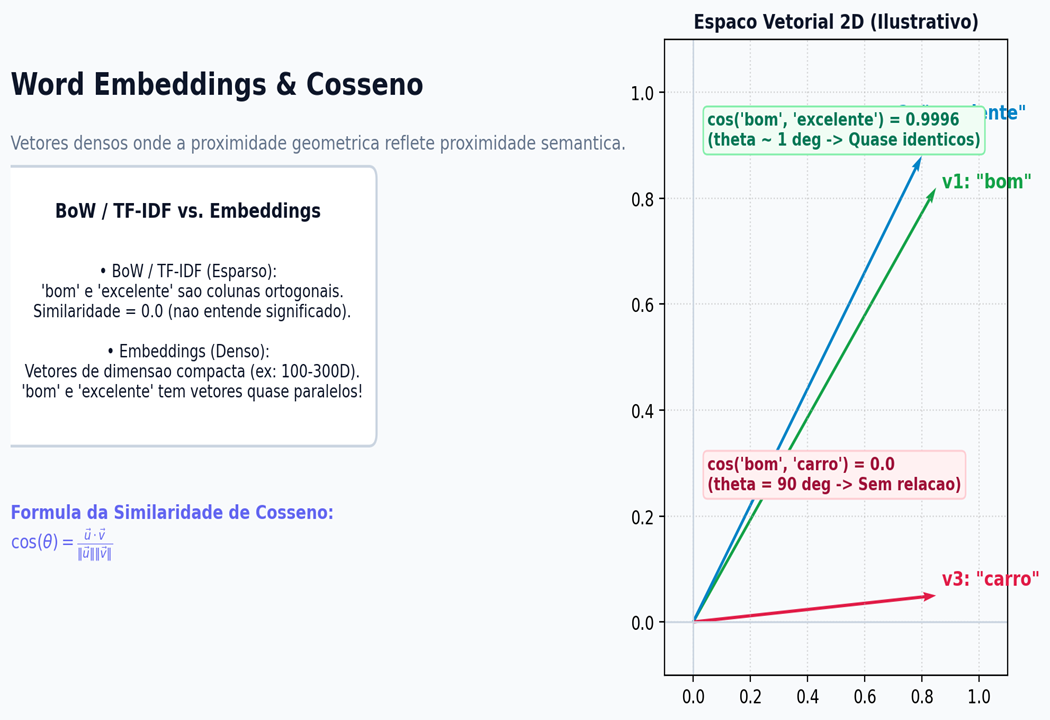

`bom` e `excelente` ficam quase colados (cosseno perto de 1); `bom` e `carro` não têm relação nenhuma (cosseno 0).

### 1.6 Revisão da teoria básica de  Machine Learning

Existem três grandes paradigmas de aprendizado de máquina; vale situar os três antes de focar no que usamos hoje.

- **Aprendizado supervisionado** (o que usamos hoje e na Sessão 07): cada exemplo de treino já vem com a resposta certa (o *rótulo*). No caso de análise de sentimento, o rótulo é "positivo" ou "negativo" — alguém já leu e classificou cada review antes.
- **Aprendizado não supervisionado**: não tem rótulo nenhum — o algoritmo só recebe os dados e precisa encontrar estrutura sozinho (agrupar itens parecidos, reduzir dimensões, encontrar padrão), sem ninguém dizer qual é a resposta certa. Um exemplo concreto com o que já temos hoje: se agrupássemos os vetores TF-IDF das reviews por proximidade, sem usar o rótulo "positivo"/"negativo" que demos a elas, deixando o algoritmo descobrir sozinho quais reviews se parecem — isso seria não supervisionado.
- **Aprendizado por reforço**: não tem rótulo fixo nem estrutura escondida — tem um agente que toma decisões, recebe uma recompensa (ou penalidade) pelo resultado, e ajusta o comportamento pra maximizar recompensa ao longo do tempo. É assim que modelos como o ChatGPT são ajustados depois do treino inicial: humanos comparam pares de respostas e dizem qual é melhor, e esse julgamento vira recompensa — a técnica se chama **RLHF** (*Reinforcement Learning from Human Feedback*, OUYANG et al., 2022). Vamos ver mais na Sessão 09-10 (Chatbots e RAG).

| Paradigma | Tem "resposta certa" dada? | Exemplo de hoje/do curso |
|---|---|---|
| Supervisionado | Sim, rótulo humano | Classificar review como positiva/negativa |
| Não supervisionado | Não — só estrutura nos dados | Agrupar reviews parecidas sem usar o rótulo |
| Por reforço | Não — recompensa/penalidade pelo resultado | RLHF ajustando um chatbot (Sessões 09-10) |

- **Treino e teste**: nunca se avalia um modelo nos mesmos dados usados pra treiná-lo. O conjunto é dividido: uma parte (normalmente 70-80%) treina, o resto mede o desempenho depois.
- **O que "treinar um modelo" significa**: no caso supervisionado, o algoritmo ajusta parâmetros internos até prever o rótulo certo na maior parte das vezes, sem decorar caso a caso.

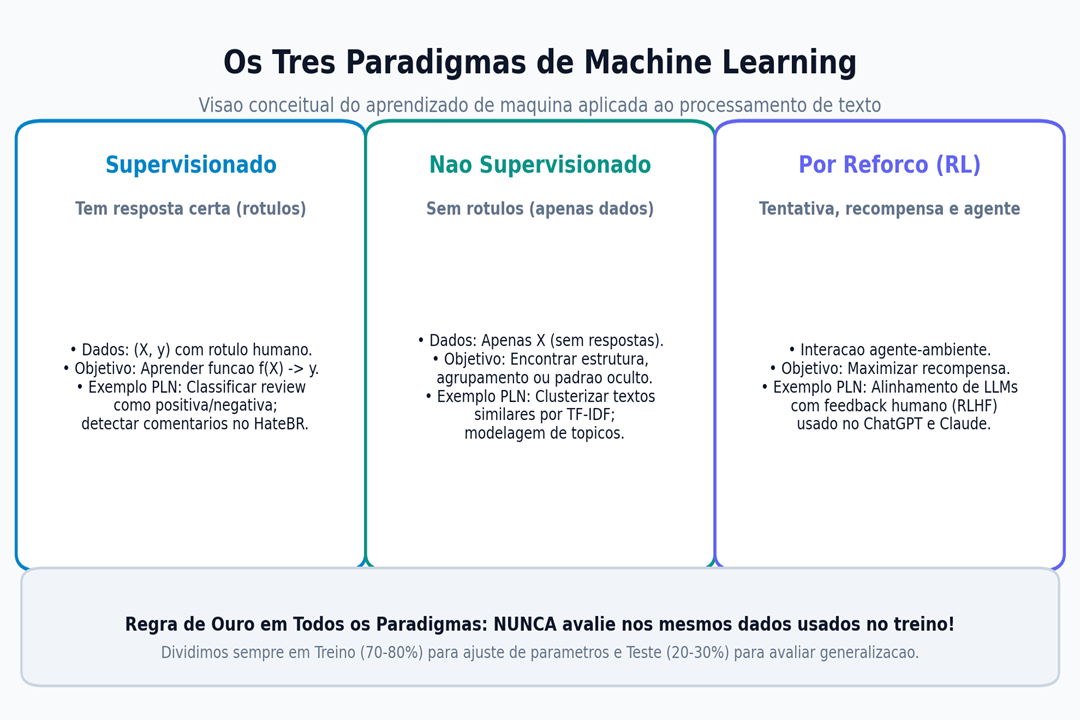

In [ ]:
reviews = [
    "produto excelente, chegou rapido, adorei",
    "produto horrivel, chegou quebrado, nao funciona",
    "nao gostei, atendimento pessimo",
    "amei o produto, super recomendo",
]

In [ ]:
# Define as categorias (o gabarito real) correspondentes a cada frase da lista 'reviews'
rotulos = ["positivo", "negativo", "negativo", "positivo"]

# Divide os textos (X) e os rótulos (y) em conjuntos de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    reviews, rotulos, test_size=0.5, random_state=42
)

# Exibe as 2 frases que o modelo usará para aprender os padrões
print("Treino:", X_treino)
# Exibe as 2 frases ocultas que usaremos depois para testar o modelo
print("Teste: ", X_teste)

O ***random_state=42*** serve para garantir a reprodutibilidade do seu código.

Como a função **train_test_split** embaralha os dados aleatoriamente antes de dividi-los, se você não usar o random_state, cada vez que você rodar a célula do notebook, as frases sorteadas para o treino e para o teste serão diferentes.

Ao definir um número fixo para esse parâmetro (uma "semente" ou seed), você "trava" essa aleatoriedade. O sorteio ainda acontece, mas ele acontecerá sempre da mesma forma.

## Por dentro do Naive Bayes — o primeiro algoritmo de verdade

Pra sair do conceito abstrato "o algoritmo ajusta parâmetros" e ver um exemplo de verdade, vale abrir o **Naive Bayes** — um bom primeiro algoritmo pra conhecer, porque é simples de entender, bem estatístico (sai direto do Teorema de Bayes) e historicamente um dos mais usados em PLN, principalmente em filtro de spam e classificação de texto (GÉRON, 2019).

A ideia do Teorema de Bayes: a probabilidade de uma classe dado um conjunto de palavras é proporcional à probabilidade de ver essas palavras dado a classe, vezes a probabilidade da classe em si:

```
P(classe | palavras) ∝ P(palavras | classe) × P(classe)
Resumindo: A probabilidade de uma classe, dadas as palavras, é proporcional à probabilidade dessas palavras ocorrerem na classe multiplicada pela probabilidade original da classe.
```

O "naive" (ingênuo) do nome vem de uma simplificação: o algoritmo assume que cada palavra aparece de forma **independente** das outras, dado a classe — o que na prática é falso (a gramática cria dependência entre palavras), mas funciona surpreendentemente bem pra classificação de texto, justamente porque BoW e TF-IDF já tratam cada palavra como uma coluna independente da outra.

Vamos calcular na mão, com um corpus de brinquedo de 4 documentos, contando palavras por classe, calculando `P(palavra | classe)` com suavização de Laplace (+1, pra nunca dar probabilidade zero a uma palavra nunca vista naquela classe), e combinando via Bayes:

In [ ]:
from collections import Counter

# Corpus com frases e suas respectivas classes positivas ou negativas (gabarito)
docs = [
    ("otimo produto rapido", "pos"),
    ("produto excelente", "pos"),
    ("produto pessimo lento", "neg"),
    ("horrivel nao funciona", "neg"),
]

# Prepara dicionários para contar as palavras separadas por classe
contagem = {"pos": Counter(), "neg": Counter()}
# Prepara dicionário para contar quantos documentos (frases) existem por classe
total_docs = {"pos": 0, "neg": 0}

# Percorre cada frase e sua classe dentro da nossa base de dados
for texto, classe in docs:
    # Conta +1 documento para a classe correspondente
    total_docs[classe] += 1
    # Quebra a frase em palavras soltas e percorre cada uma delas
    for palavra in texto.split():
        # Registra +1 para essa palavra dentro dessa classe específica
        contagem[classe][palavra] += 1

# Pega todas as palavras únicas do nosso corpus inteiro para formar o vocabulário
vocabulario = set(p for texto, _ in docs for p in texto.split())
# Guarda o tamanho total do vocabulário (necessário para a matemática de Bayes)
V = len(vocabulario)
# Conta o total absoluto de palavras usadas na classe positiva e na negativa
total_palavras = {c: sum(contagem[c].values()) for c in contagem}

# Função para calcular o P(palavra | classe) com a Suavização de Laplace
def prob_palavra_dado_classe(palavra, classe):
    # Soma +1 no numerador e +V no denominador para impedir probabilidade zero
    return (contagem[classe][palavra] + 1) / (total_palavras[classe] + V)

# Função para calcular a probabilidade base da classe P(classe)
def prob_classe_prior(classe):
    # Divide o total de frases de uma classe pelo total geral de frases
    return total_docs[classe] / len(docs)

# Motor principal que junta as probabilidades para prever uma nova frase
def classificar(frase):
    # Dicionário para guardar a pontuação final da frase em cada classe
    scores = {}
    # Testa a mesma frase tanto para "pos" quanto para "neg"
    for classe in ["pos", "neg"]:
        # Começa a conta usando a probabilidade base daquela classe
        score = prob_classe_prior(classe)
        # Analisa cada palavra da frase nova de forma independente (o lado "Naive")
        for p in frase.split():
            # Multiplica a probabilidade de cada palavra aparecer nessa classe
            score *= prob_palavra_dado_classe(p, classe)
        # Salva o resultado matemático final para essa classe
        scores[classe] = score
    # Retorna as duas pontuações para podermos comparar
    return scores

# Lista de frases inéditas para testar se o modelo aprendeu
for teste in ["produto otimo", "produto pessimo", "produto rapido e excelente"]:
    # Envia a frase para o modelo e recebe as probabilidades
    scores = classificar(teste)
    # Exibe a frase, os scores (arredondados) e crava a classe vencedora (maior score)
    print(teste, "->", {k: round(v, 6) for k, v in scores.items()}, "  previsão:", max(scores, key=scores.get))

Agora o mesmo corpus, mesmas frases, usando o `MultinomialNB` do scikit-learn — pra conferir se bate:

### USANDO O ALGORITMO NAIVE BAYES

In [ ]:
# Conferindo com o MultinomialNB do scikit-learn
textos = [d[0] for d in docs]
classes = [d[1] for d in docs]

In [ ]:
classes

In [ ]:
textos

In [ ]:
cv_nb = CountVectorizer()
X_nb = cv_nb.fit_transform(textos)
clf_nb = MultinomialNB()
clf_nb.fit(X_nb, classes)

testes = ["produto otimo", "produto pessimo", "produto rapido e excelente", "odiei esse produto","estava tudo errado com o pedido não gostei", "não foi a cor que eu pedi, que saco"]
print(clf_nb.predict(cv_nb.transform(testes)))

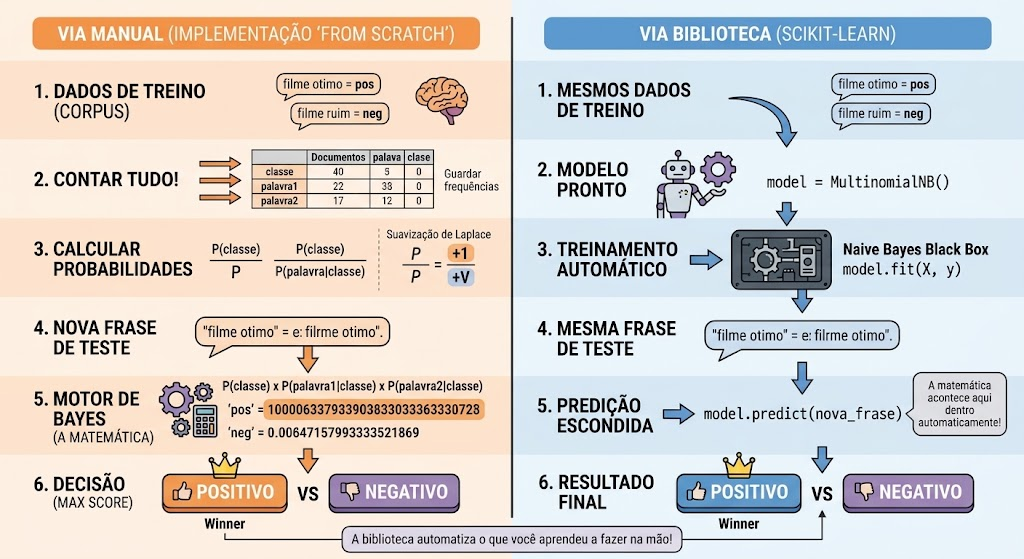

**Bateu exatamente com o cálculo na mão.** É isso que "treinar um modelo" significa no caso do Naive Bayes: contar frequências por classe, aplicar o Teorema de Bayes, escolher a classe com maior probabilidade — sem nenhuma mágica escondida. É por isso que o estudo de caso a seguir (e o classificador da Sessão 07) usam exatamente esse algoritmo: rápido de treinar, funciona bem com vetores esparsos como BoW/TF-IDF, e é fácil de entender por dentro.

### 1.7 Estudo de caso — HateBR: detector ingênuo vs. classificador de verdade

Nas Sessões 03-04 escrevemos `contem_linguagem_inadequada`, um detector baseado numa lista de 3 palavras proibidas. Chegou a hora de comparar com um classificador de Machine Learning de verdade, treinado sobre o mesmo dataset HateBR.

In [ ]:
# HateBR — mesmo dataset das Sessões 03-04
url_hatebr = "https://raw.githubusercontent.com/franciellevargas/HateBR/main/dataset/HateBR.csv"
hatebr = pd.read_csv(url_hatebr)

print("Setup pronto. HateBR:", hatebr.shape)

In [ ]:
X = hatebr["comentario"].astype(str)
y = hatebr["label_final"]  # 1 = ofensivo, 0 = não ofensivo (3.500 de cada, dataset balanceado)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
import matplotlib.pyplot as plt

# 1. Conta a quantidade de 0s e 1s na variável 'y' e gera o gráfico de barras
ax = y.value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], figsize=(8, 5))

# 2. Deixa o gráfico mais explicativo para os alunos
plt.title('Balanceamento de Classes - Dataset HateBR', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Quantidade de Comentários', fontsize=12)

# 3. Substitui os números 0 e 1 por nomes mais claros no eixo X
ax.set_xticklabels(['Não Ofensivo (0)', 'Ofensivo (1)'], rotation=0)

# 4. Exibe o gráfico
plt.show()

## Abaixo estamos usando a função que fizemos na primeira aula, podem ver que ela ainda foi uma acurácia de 50%, ele praticamente chuta e acerta 50% das frases.

In [ ]:
pred_ingenuo = X_teste.apply(lambda t: 1 if contem_linguagem_inadequada(t, lista_proibida) else 0)
print("Acurácia do detector ingênuo:", round(accuracy_score(y_teste, pred_ingenuo), 4))

**51%** — pouco melhor que jogar uma moeda pra decidir. Agora um classificador real, comparando unigrama, unigrama+bigrama e unigrama+bigrama+trigrama:

## Agora sim o naive Bayes

In [ ]:
# Testa 3 cenários: palavras isoladas (1,1), duplas (1,2) e trios (1,3) de palavras
for nome, ngram_range in [("unigrama", (1,1)), ("uni+bigrama", (1,2)), ("uni+bi+trigrama", (1,3))]:

    # Cria o transformador TF-IDF configurado com o tamanho do bloco de palavras da vez
    vetorizador = TfidfVectorizer(ngram_range=ngram_range)
    # Aprende o vocabulário das frases de treino e já as transforma em números (matriz)
    Xtr = vetorizador.fit_transform(X_treino)
    # Apenas transforma o teste em números usando o vocabulário que acabou de aprender
    Xte = vetorizador.transform(X_teste)

    # Cria o algoritmo Naive Bayes (aquele que vimos a matemática por trás)
    modelo = MultinomialNB()
    # Treina o algoritmo entregando os textos em números (Xtr) e o gabarito (y_treino)
    modelo.fit(Xtr, y_treino)
    # Pede para o modelo adivinhar as classes (ofensivo/não ofensivo) das frases de teste
    predicao = modelo.predict(Xte)

    # Compara a adivinhação do modelo com o gabarito real para calcular a taxa de acerto
    acc = accuracy_score(y_teste, predicao)
    # Imprime o nome do teste, o tamanho do vocabulário gerado e a acurácia final
    print(f"{nome:<18} vocabulário={len(vetorizador.vocabulary_):>6}  acurácia={acc:.4f}")

In [ ]:
print("🤖 Classificador Interativo (Digite 'sair' para encerrar)")
print("-" * 60)

while True:
    # 1. Abre o campo de texto para o aluno digitar a frase
    frase = input("Digite uma frase: ")

    # 2. Condição para quebrar o loop e parar o programa
    if frase.lower() == 'sair':
        print("Encerrando o teste. Até mais! 👋")
        break

    # 3. Transforma a frase digitada (Atenção: precisa estar dentro de uma lista [])
    X_nova = vetorizador.transform([frase])

    # 4. O modelo faz a previsão (pegamos o índice [0] porque o resultado é um array)
    predicao = modelo.predict(X_nova)[0]

    # 5. Traduz o rótulo numérico para texto e exibe na tela
    if predicao == 1:
        print("-> 🚨 OFENSIVO\n")
    else:
        print("-> 🕊️ NÃO OFENSIVO\n")

## E se aplicar os pre processamentos que aprendemos na aula anterior? o modelo melhoraria?

**Nota:** o spaCy marca "não" como stopword — então `remover_stopwords=True` sozinho apaga "não" de todo comentário antes de vetorizar, o que vai contra a lição da Sessão 03. Vamos comparar as duas versões (removendo "não" e preservando "não") pra ver se isso faz diferença de verdade na acurácia — e a resposta não é tão óbvia quanto parece.

In [ ]:
import spacy

# Tenta carregar o modelo. Se não encontrar, faz o download automático (como na Sessão 03)
try:
    nlp = spacy.load("pt_core_news_sm")
except OSError:
    print("Modelo 'pt_core_news_sm' não encontrado. Baixando agora...")
    !python -m spacy download pt_core_news_sm
    nlp = spacy.load("pt_core_news_sm")
    print("Download concluído!")

def limpar_texto_flexivel(texto, minusculo=True, tirar_pontuacao=True, remover_stopwords=True, lematizar=True, preservar_negacao=False):
    # 1. Converte para minúsculo logo de cara, se o parâmetro for True
    texto_processar = texto.lower() if minusculo else texto

    # 2. O spaCy processa o texto
    doc = nlp(texto_processar)
    tokens = []

    for tok in doc:
        # 3. Verifica pontuações e números (mantém apenas letras se True)
        if tirar_pontuacao and not tok.is_alpha:
            continue

        # 4. Verifica as stopwords (descarta se True) — MAS o spaCy marca "não" como stopword também.
        #    Se preservar_negacao=True, a gente abre uma exceção pra ela, do mesmo jeito que já
        #    fizemos com stop_pt_sem_negacao nas Sessões 03-04.
        if remover_stopwords and tok.is_stop:
            if preservar_negacao and tok.text == "não":
                pass  # não descarta "não" mesmo sendo stopword
            else:
                continue

        # 5. Aplica a lematização ou mantém o texto original
        forma = tok.lemma_ if lematizar else tok.text
        tokens.append(forma)

    # Junta as palavras de volta em uma frase (string)
    return " ".join(tokens)

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Carrega os dados (seu código original)
url_hatebr = "https://raw.githubusercontent.com/franciellevargas/HateBR/main/dataset/HateBR.csv"
hatebr = pd.read_csv(url_hatebr)

X = hatebr["comentario"].astype(str)
y = hatebr["label_final"]  # 1 = ofensivo, 0 = não ofensivo

# 2. Aplica a limpeza em toda a base de dados ANTES da divisão
print("Iniciando a limpeza... aguarde ⏳")

# Passamos a função pelo nome (sem parênteses) e os parâmetros na sequência
X_limpo = X.apply(limpar_texto_flexivel, minusculo=True, tirar_pontuacao=True, remover_stopwords=True, lematizar=True)

print("Limpeza concluída! ✅")

# 3. Agora sim, divide a base já pré-processada em Treino e Teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_limpo, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Exibe como ficou a primeira frase do treino para validar
print("\nExemplo de texto pronto para treinar:")
print(X_treino.iloc[0])

In [ ]:
X_treino

In [ ]:
# Testa 3 cenários: palavras isoladas (1,1), duplas (1,2) e trios (1,3) de palavras
for nome, ngram_range in [("unigrama", (1,1)), ("uni+bigrama", (1,2)), ("uni+bi+trigrama", (1,3))]:

    # Cria o transformador TF-IDF configurado com o tamanho do bloco de palavras da vez
    vetorizador = TfidfVectorizer(ngram_range=ngram_range)
    # Aprende o vocabulário das frases de treino e já as transforma em números (matriz)
    Xtr = vetorizador.fit_transform(X_treino)
    # Apenas transforma o teste em números usando o vocabulário que acabou de aprender
    Xte = vetorizador.transform(X_teste)

    # Cria o algoritmo Naive Bayes (aquele que vimos a matemática por trás)
    modelo = MultinomialNB()
    # Treina o algoritmo entregando os textos em números (Xtr) e o gabarito (y_treino)
    modelo.fit(Xtr, y_treino)
    # Pede para o modelo adivinhar as classes (ofensivo/não ofensivo) das frases de teste
    predicao = modelo.predict(Xte)

    # Compara a adivinhação do modelo com o gabarito real para calcular a taxa de acerto
    acc = accuracy_score(y_teste, predicao)
    # Imprime o nome do teste, o tamanho do vocabulário gerado e a acurácia final
    print(f"[SEM preservar não]     {nome:<18} vocabulário={len(vetorizador.vocabulary_):>6}  acurácia={acc:.4f}")

### Agora preservando "não" — pra comparar de verdade

In [ ]:
print("Iniciando a limpeza preservando 'não'... aguarde ⏳")
X_limpo_com_nao = X.apply(limpar_texto_flexivel, minusculo=True, tirar_pontuacao=True,
                           remover_stopwords=True, lematizar=True, preservar_negacao=True)
print("Limpeza concluída! ✅")

X_treino_nao, X_teste_nao, y_treino_nao, y_teste_nao = train_test_split(
    X_limpo_com_nao, y, test_size=0.2, random_state=42, stratify=y
)
print("\nExemplo de texto pronto para treinar (preservando não):")
print(X_treino_nao.iloc[0])

In [ ]:
for nome, ngram_range in [("unigrama", (1,1)), ("uni+bigrama", (1,2)), ("uni+bi+trigrama", (1,3))]:
    vetorizador = TfidfVectorizer(ngram_range=ngram_range)
    Xtr = vetorizador.fit_transform(X_treino_nao)
    Xte = vetorizador.transform(X_teste_nao)

    modelo = MultinomialNB()
    modelo.fit(Xtr, y_treino_nao)
    predicao = modelo.predict(Xte)

    acc = accuracy_score(y_teste_nao, predicao)
    print(f"[preservando não]       {nome:<18} vocabulário={len(vetorizador.vocabulary_):>6}  acurácia={acc:.4f}")

#### Comparando as duas versões (testado)

| | Unigrama | Uni+bigrama | Uni+bi+trigrama |
|---|---|---|---|
| **Sem pré-processar** (material original) | 85,00% | 84,93% | 84,57% |
| **Pré-processado, removendo "não"** | 85,71% | 85,36% | 85,57% |
| **Pré-processado, preservando "não"** | 85,64% | 85,00% | 85,07% |

Resultado real, e um pouco contra a intuição: preservar "não" **não melhorou** a acurácia aqui — na verdade ficou levemente pior que removê-lo (85,64% vs. 85,71% no unigrama, e uma diferença um pouco maior no uni+bigrama e uni+bi+trigrama).

Isso **não invalida** a lição da Sessão 03 sobre nunca remover "não" às cegas — pra léxico de sentimento (Parte 2 de hoje) e pra leitura humana, perder o "não" muda o sentido inteiro da frase. Mas pra um classificador de Naive Bayes com TF-IDF, que já enxerga centenas de outras palavras carregadas em cada comentário ofensivo, o "não" sozinho não carrega tanto peso relativo — e removê-lo até reduz um pouco de ruído no vocabulário. É um bom lembrete de que uma regra que faz sentido pra uma técnica (léxico) não necessariamente muda o resultado de outra (classificador supervisionado) — só dá pra saber testando as duas, exatamente como fizemos aqui.

Dois resultados pra reter:

1. **O salto grande é de detector ingênuo pra classificador**, não entre os classificadores: 51% → 85%. Treinar um modelo sobre 5.600 exemplos reais bate de longe qualquer lista de palavras escrita à mão.
2. **Adicionar bigrama e trigrama não melhorou a acurácia — piorou ligeiramente**, mesmo o vocabulário crescendo de ~10 mil pra mais de 110 mil colunas. Não significa que n-grama seja ideia ruim — significa que, neste dataset, com este classificador, o ganho teórico de contexto não compensou o custo de um vocabulário muito maior e mais esparso. É uma lição sobre Machine Learning: uma técnica que ajuda na teoria não necessariamente ajuda *neste* dado — só dá pra saber testando.

Guarda o número **85%** — ele volta na Parte 2, comparado com uma abordagem bem mais simples.

## Parte 2 — Análise de Sentimentos I: abordagens léxicas

### 2.1 O que é análise de sentimento

Análise de sentimento é a tarefa de decidir se um texto expressa uma opinião **positiva**, **negativa** ou **neutra**. É uma das aplicações mais usadas de PLN — de avaliação de produto a monitoramento de rede social (RUSSELL, 2019).

Existem duas famílias de abordagem: **baseada em léxico** (o que vemos hoje — não precisa de dado rotulado, só de um dicionário de palavras com peso de sentimento) e **baseada em classificador supervisionado** (o que vimos na Parte 1 pra ofensividade, e que retomamos especificamente pra sentimento na Sessão 07).

### 2.2 A ideia do léxico

Um **léxico de sentimento** é uma lista de palavras, cada uma com uma polaridade — normalmente um número: positivo, negativo, ou zero (neutro). Pra saber o sentimento de uma frase, soma-se a polaridade de cada palavra da frase que está no léxico.

```
"o atendimento foi ótimo e rápido"
  ótimo   -> +1
  rápido  -> +1
  soma    -> +2  (positivo)
```

Usamos o **OpLexicon** (versão 3.0), um léxico de sentimento em português com mais de 24 mil palavras, cada uma marcada como adjetivo com polaridade -1, 0 ou +1, desenvolvido na PUC-RS (SOUZA; VIEIRA, 2012). Ele carrega direto por URL, sem precisar baixar nada manualmente:

In [ ]:
url_lexico = "https://raw.githubusercontent.com/marlovss/OpLexicon/main/OpLexicon.csv"
lexico_df = pd.read_csv(url_lexico, header=None, names=["palavra", "classe", "polaridade"])
lexico = dict(zip(lexico_df["palavra"], lexico_df["polaridade"]))

print("Total de palavras no léxico:", len(lexico))
print("bom      ->", lexico.get("bom"))
print("péssimo  ->", lexico.get("péssimo"))

In [ ]:
lexico_df

**Atenção com acento:** o léxico usa a forma acentuada correta ("ótimo", "péssimo", "horrível") — se você tivesse aplicado `remover_acentos` (Sessão 03) antes de consultar o léxico, "ótimo" viraria "otimo" e não seria encontrado. Nem toda normalização serve pra toda tarefa — aqui, o acento importa.

### 2.3 Somando a polaridade de uma frase

In [ ]:
def polaridade_frase(frase, lexico):
    # Usa regex para pegar apenas palavras com letras (ignora pontuação) e joga para minúsculo
    palavras = re.findall(r"[a-zà-úA-ZÀ-Ú]+", frase.lower())
    # Inicia o "saldo" (a pontuação total) da frase com zero
    soma = 0
    # Cria uma lista vazia para anotar quais palavras do nosso dicionário apareceram no texto
    encontradas = []
    # Inicia um loop para analisar cada palavra isolada da frase
    for p in palavras:
        # Verifica se a palavra está no nosso dicionário (léxico) e se tem algum valor associado
        if p in lexico and lexico[p] != 0:
            # Pega o valor da palavra (ex: +1 para bom, -1 para ruim) e adiciona ao saldo total
            soma += lexico[p]
            # Guarda a palavra e a nota dela na lista para sabermos o que motivou a decisão
            encontradas.append((p, lexico[p]))
    # Devolve o saldo final da frase e a listinha de palavras que influenciaram o resultado
    return soma, encontradas

# Lista com três frases simples para validar se a nossa lógica matemática está funcionando
testes = [
    # 🟢 Claramente Positivas
    "A interface do aplicativo é maravilhosa e super intuitiva",
    "Fantástico! Resolveu todos os meus problemas rapidamente",
    "O código rodou de primeira, estou muito satisfeito",
    "Simplesmente espetacular, superou minhas expectativas",
    "Fiquei encantada com o cuidado e a dedicação da equipe",
    "Projeto esplêndido, documentação impecável e entrega ágil",

    # 🔴 Claramente Negativas
    "O sistema travou logo no início, experiência horrível",
    "Um desperdício de tempo e dinheiro, infelizmente",
    "O design é medonho, parece uma ferramenta amadora",
    "Achei o conteúdo raso e completamente decepcionante",
    "Quebrou no primeiro uso, qualidade muito duvidosa",
    "A navegação é confusa, layout poluído e suporte inútil",

    # 🟡 Mistas ou Neutras (Ótimas para ver como a soma se comporta)
    "A entrega atrasou, mas o suporte foi educado e prestativo",
    "Gostei da agilidade, mas detestei a falta de opções",
    "É apenas razoável, não tem nada de inovador ou especial",
    "Não sei dizer se é bom ou ruim, o resultado é indiferente",

    # ⚠️ Desafios para o Léxico (Negações e Ironias)
    "Não gostei muito do resultado final", # Léxico pode ver "gostei" e dar positivo
    "O produto não é ruim", # Léxico pode ver "ruim" e dar negativo
    "Nossa, que sistema maravilhoso, só travou cinco vezes hoje", # Ironia pura
    "Estou morrendo de rir com esse erro bizarro no banco de dados" # Sentimento confuso
]
# Loop para testar cada frase da lista uma por uma
for frase in testes:
    # Chama a função passando a frase e o léxico, e guarda os dois retornos nas variáveis
    soma, achadas = polaridade_frase(frase, lexico)
    # Imprime a frase (formatada para alinhar), a pontuação total (com sinal de + ou -) e as palavras lidas
    print(f"{frase!r:38} soma={soma:+d}  palavras={achadas}")

### 2.4 O problema da negação

"Não" volta a aparecer — o mesmo problema que já vimos nas stopwords (Sessão 03) e nos n-gramas (Parte 1 de hoje):

In [ ]:
print(polaridade_frase("o produto não é bom", lexico))
print(polaridade_frase("o produto não é ruim", lexico))

**Os dois saem invertidos.** "Não é bom" deveria ser negativo, e "não é ruim" deveria ser positivo — mas a soma simples ignora completamente o "não" (ele nem está no léxico de adjetivos) e conta só a palavra de sentimento.

Um jeito parcial de resolver: olhar as poucas palavras *antes* de cada palavra de sentimento, e inverter a polaridade se houver um "não" na janela:

In [ ]:
def polaridade_com_negacao(frase, lexico, janela=3):
    palavras = re.findall(r"[a-zà-úA-ZÀ-Ú]+", frase.lower())
    soma = 0
    for i, p in enumerate(palavras):
        if p in lexico and lexico[p] != 0:
            peso = lexico[p]
            contexto_antes = palavras[max(0, i - janela):i]
            if "não" in contexto_antes:
                peso = -peso
            soma += peso
    return soma

print(polaridade_com_negacao("o produto não é bom", lexico))
print(polaridade_com_negacao("o produto não é ruim", lexico))

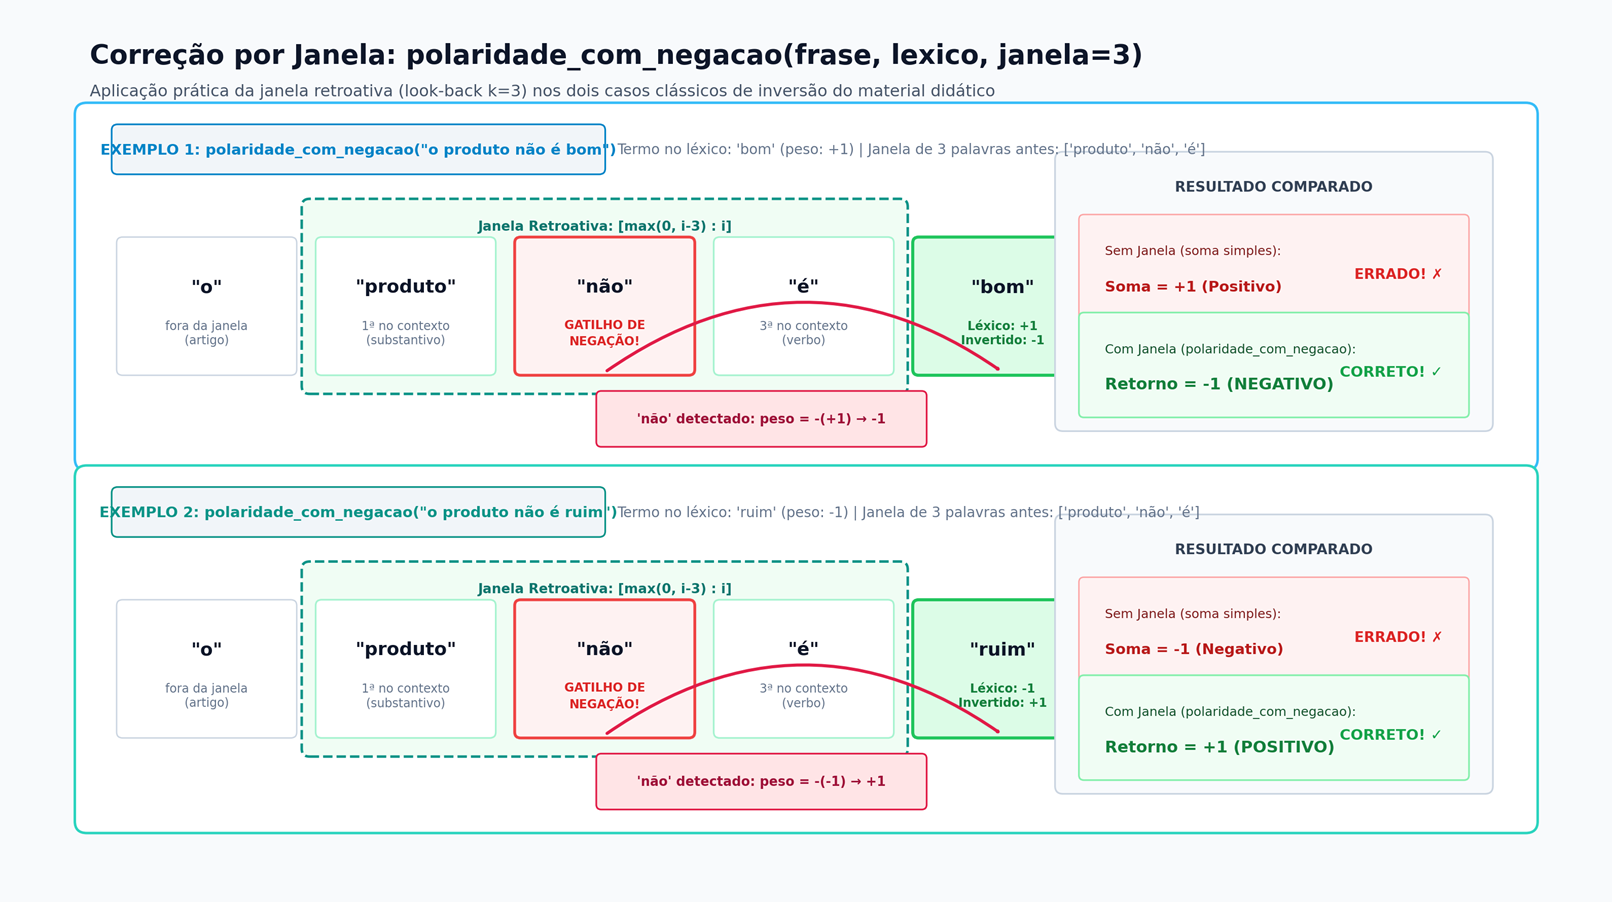

Agora os dois saem corretos. Não é perfeito — "janela de 3 palavras" é uma escolha arbitrária, e frases com negação mais distante da palavra de sentimento ainda escapam — mas já resolve o caso mais comum.

### 2.5 Intensificadores — outra limitação

In [ ]:
print(polaridade_frase("o produto é bom", lexico))
print(polaridade_frase("o produto é muito bom", lexico))

As duas frases saem com a mesma polaridade — "muito" não está no léxico (é advérbio, o OpLexicon cobre principalmente adjetivos), então ele simplesmente é ignorado. Um léxico mais completo, ou uma lista separada de intensificadores multiplicando o peso da palavra seguinte, resolveria isso — não vamos implementar hoje, mas fica registrada a limitação.

### 2.6 Quando o léxico falha de vez

Nenhuma soma de palavras resolve ironia ou sarcasmo — um dos sete desafios do PLN que já vimos na Sessão 02:

```
"Que atendimento incrível, esperei 3 horas."
```

"incrível" está no léxico como positivo — a soma dá positivo, mas o sentimento real da frase é claramente negativo. Léxico não entende contexto, só conta palavras.

### 2.7 Estudo de caso — o léxico aplicado ao HateBR

Voltando ao dataset da Parte 1: um comentário com polaridade negativa costuma ter mais chance de ser ofensivo? Vamos testar — classificando como "ofensivo" todo comentário cuja soma de polaridade sai negativa:

In [ ]:
def polaridade_frase_simples(frase, lexico):
    palavras = re.findall(r"[a-zà-úA-ZÀ-Ú]+", str(frase).lower())
    return sum(lexico.get(p, 0) for p in palavras)

pred_lexico = X_teste.apply(lambda t: 1 if polaridade_frase_simples(t, lexico) < 0 else 0)
print("Acurácia do léxico:", round(accuracy_score(y_teste, pred_lexico), 4))

Isso fecha um comparativo de três abordagens pro **mesmo problema, mesmo dado, mesmo conjunto de teste**:

| Abordagem | Acurácia |
|---|---|
| Detector ingênuo (lista de 3 palavras, Sessões 03-04) | 51% |
| Léxico de sentimento (hoje) | 67% |
| Classificador TF-IDF + Naive Bayes (Parte 1 de hoje) | 85% |

O léxico melhora bastante sobre o detector ingênuo — reconhece muito mais palavras carregadas de sentimento do que uma lista de 3 termos — mas ainda fica bem atrás do classificador treinado, que aprende padrões diretamente dos 5.600 exemplos anotados em vez de depender de um dicionário genérico escrito pra outro domínio.

A ideia de ligar uma palavra de sentimento a um alvo específico (ex.: "bateria fraca" é negativo *sobre a bateria*, não sobre o produto inteiro) aparece aqui só implícita na soma — ela volta de forma automatizada e mais precisa na Sessão 11, quando temos POS tagging e `token.head` pra ligar cada adjetivo ao substantivo certo.

---

## Para aprofundar

- GÉRON, A. *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn & TensorFlow.* Alta Books, 2019.
- HOBSON, L.; COLE, H.; HANNES, H. *Natural Language Processing in Action.* Manning, 2019.
- MCKINNEY, W. *Python Para Análise de Dados.* Novatec, 2018.
- RUSSELL, M. A. *Mineração de Dados da Web Social.* Novatec, 2019.
- VARGAS, F. et al. *HateBR: A Large Expert Annotated Corpus of Brazilian Instagram Comments for Offensive Language and Hate Speech Detection.* LREC, 2022. Dataset: [github.com/franciellevargas/HateBR](https://github.com/franciellevargas/HateBR)
- SOUZA, M.; VIEIRA, R. *Sentiment Analysis on Twitter Data for Portuguese Language.* PROPOR, 2012.
- OpLexicon v3.0 — léxico de sentimento em português, PUC-RS. [inf.pucrs.br/linatural/wordpress/recursos-e-ferramentas/oplexicon](https://www.inf.pucrs.br/linatural/wordpress/recursos-e-ferramentas/oplexicon/) · dados: [github.com/marlovss/OpLexicon](https://github.com/marlovss/OpLexicon)
- OUYANG, L. et al. *Training language models to follow instructions with human feedback.* OpenAI, 2022. [arxiv.org/abs/2203.02155](https://arxiv.org/abs/2203.02155)

Fim da prática guiada. Os exercícios de entrega estão em `notebook_exercicios.ipynb`.

---

## Desafio — comparando os três métodos numa base bem mais suja

Até agora usamos o HateBR, que já vem bem preparado (uma coluna de texto, um rótulo limpo). Bases do mundo real raramente chegam assim. Vamos usar o **B2W-Reviews01** — mais de 130 mil avaliações reais de produtos da Americanas.com, coletadas em 2018, com nome do reviewer anonimizado, nota de 1 a 5 estrelas e se a pessoa recomendaria o produto a um amigo (CC BY-NC-SA 4.0).

Fonte: [github.com/b2wdigital/b2w-reviews01](https://github.com/b2wdigital/b2w-reviews01)

Essa base é genuinamente suja: tem linha sem texto, review duplicada, texto em CAIXA ALTA, preço colado no meio da frase ("R$1994.20,eu consegui..."), números, pontuação estranha. Antes de classificar qualquer coisa, precisa limpar.

In [ ]:
url_b2w = "https://raw.githubusercontent.com/b2wdigital/b2w-reviews01/master/B2W-Reviews01.csv"
b2w = pd.read_csv(url_b2w, low_memory=False)

print("Linhas:", len(b2w))
print("Colunas:", b2w.columns.tolist())
print()
print("Nulos em review_text:", b2w["review_text"].isna().sum())
print("Nulos em recommend_to_a_friend:", b2w["recommend_to_a_friend"].isna().sum())
print("Reviews duplicadas:", b2w["review_text"].duplicated().sum())
print()
print(b2w[["overall_rating", "recommend_to_a_friend", "review_text"]].sample(3, random_state=1).to_string())

### Passo 1 — Limpar e preparar

O rótulo que vamos prever é `recommend_to_a_friend` ("Yes"/"No" — vira 1/0). Antes de vetorizar:

1. Tire as linhas com `review_text` ou `recommend_to_a_friend` nulos (`.dropna`).
2. Tire as reviews duplicadas (`.drop_duplicates(subset=["review_text"])`).
3. **(Sua vez)** Escreva uma função `limpar_review(texto)` usando regex que:
   - Converte pra minúsculas;
   - Troca valores em reais (`R$1994.20`, `r$ 50,00` etc.) por um marcador `" dinheiro "` (dica: `r'r\$\s*\d+[.,]?\d*'`);
   - Troca qualquer número restante por `" numero "`;
   - Remove tudo que não for letra (acentuada ou não) ou espaço;
   - Colapsa espaços duplos.
4. Aplique a função em toda a coluna `review_text` com `.apply(...)`.
5. Por que faz sentido trocar preço/número por um marcador em vez de simplesmente apagar? (Pense no que aconteceria com "R$1994.20,eu consegui comprar" se você só apagasse os dígitos sem colocar nada no lugar.)

Amostre **6.000 linhas** (`.sample(6000, random_state=1)`) antes de seguir — a base inteira é grande demais pra rodar tudo em segundos no Colab gratuito.

In [ ]:
# Sua vez — Passo 1
# b2w_limpo = b2w.dropna(subset=[...]).drop_duplicates(subset=[...])
# b2w_limpo = b2w_limpo.sample(6000, random_state=1)
#
# def limpar_review(texto):
#     ...
#
# b2w_limpo["texto_limpo"] = b2w_limpo["review_text"].apply(limpar_review)


### Passo 2 — Os três métodos, na mesma base

Agora repita a comparação de hoje, só que nesta base nova:

1. **Detector por palavra-chave** (como `contem_linguagem_inadequada` das Sessões 03-04): monte uma lista pequena de palavras claramente negativas ("péssimo", "horrível", "não recomendo"...) e classifique como "não recomenda" (0) qualquer review que contenha alguma delas; o resto vira "recomenda" (1).
2. **Léxico de sentimento** (`polaridade_frase_simples` + `lexico`, já carregados hoje): some a polaridade da review; se a soma for negativa, classifique como "não recomenda".
3. **Classificador TF-IDF + Naive Bayes**: repita o loop de unigrama / uni+bigrama / uni+bi+trigrama que já fizemos, agora com `X_treino`/`X_teste` vindos de `texto_limpo`.

Pra cada um, calcule a acurácia contra `recommend_to_a_friend` (convertido pra 1/0) e monte uma tabela comparando os três, igual à do material de hoje.

**Antes de comparar:** calcule também a acurácia de um "modelo" que sempre chuta a classe mais frequente (`y_treino.mode()[0]` repetido pra todo mundo). Essa base **não é balanceada** como o HateBR — vale a pena saber qual é o piso antes de comemorar qualquer acurácia.

In [ ]:
# Sua vez — Passo 2
# y = (b2w_limpo["recommend_to_a_friend"] == "Yes").astype(int)
#
# 2a. baseline "sempre a classe majoritária"
# ...
#
# 2b. detector por palavra-chave
# ...
#
# 2c. léxico de sentimento
# ...
#
# 2d. TF-IDF + Naive Bayes (uni / uni+bi / uni+bi+tri)
# ...


### Passo 3 — Reflexão

Responda com um comentário no código (não precisa de resposta "certa", mas precisa ser sua conclusão de verdade, olhando os números que você achou):

1. Qual dos três métodos ficou mais perto do teto (ML) e qual ficou mais perto do piso (baseline sempre-a-mesma-classe)?
2. Essa base tem bem mais reviews positivas (recomenda) que negativas. Isso muda como você interpreta "86% de acurácia", por exemplo? Uma acurácia alta aqui significa a mesma coisa que uma acurácia alta no HateBR (que é balanceado 50/50)?
3. Se você tivesse que escolher só **um** desses três métodos pra colocar no ar amanhã, num sistema real da loja, qual escolheria — e o que pesaria mais na decisão além da acurácia (custo computacional, interpretabilidade, precisa de dado rotulado ou não)?